In [3]:
import sys
sys.path.append("../../")

%load_ext autoreload
%autoreload 2

In [49]:
import dsrl.offline_safety_gymnasium  # type: ignore
import gymnasium as gym
import joblib
import math
import functools

import dsrl.infos as dsrl_infos
import numpy as np
import jax
import jax.numpy as jnp
from flax import nnx

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# t-SNE plot import
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


from dsrl_model.utils.models_jax import ExpCostModel, TransformerEmbedding, positionalencoding1d, l2_normalize
from dsrl_model.utils.dsrl_dataset import get_dataset_in_d4rl_format, get_neg_and_union_data_2
from dsrl_model.model_free.safecl_jax import index_fun

In [5]:
def get_data(data, start=0, end=-1):
    observations, actions, costs = data["observations"], data["actions"], data["costs"]
    return (jnp.array(observations[start:end]),
            jnp.array(actions[start:end]),
            jnp.array(costs[start:end]))

In [6]:
def load_cost_model(obs_dim, act_dim, hidden_size, path):
    restored_pure_dict = joblib.load(path)
    
    model = ExpCostModel(
        rngs=nnx.Rngs(0), x_dims=(obs_dim + act_dim), hidden_size=hidden_size
    )
    abstract_model = nnx.eval_shape(lambda: model)
    graphdef, abstract_state = nnx.split(abstract_model)
    nnx.replace_by_pure_dict(abstract_state, restored_pure_dict)
    cost_model = nnx.merge(graphdef, abstract_state)
    cost_model.eval()
    return cost_model


def load_embedding_model(obs_dim, act_dim, horizon, embd_dim, num_attentions, path):
    restored_pure_dict = joblib.load(path)
    restored_pure_dict.pop('mask')
    restored_pure_dict.pop('pos_encoding')
    
    model = TransformerEmbedding(
        rngs=nnx.Rngs(0), 
        obs_dim=obs_dim,
        act_dim=act_dim,
        horizon=horizon,
        embd_dim=embd_dim,
        num_attentions=num_attentions,
    )
    abstract_model = nnx.eval_shape(lambda: model)
    graphdef, abstract_state = nnx.split(abstract_model)
    nnx.replace_by_pure_dict(abstract_state, restored_pure_dict)
    embedding_model = nnx.merge(graphdef, abstract_state)
    
    embedding_model.mask = jnp.tril(jnp.ones((horizon, horizon)))
    embedding_model.pos_encoding = positionalencoding1d(embd_dim, horizon)
    
    embedding_model.eval()
    return embedding_model

In [7]:
def get_env(task):
    env = gym.make(task)
    obs_space, act_space = env.observation_space, env.action_space
    return env, obs_space.shape[0], act_space.shape[0]

In [8]:
@functools.partial(jax.jit, static_argnums=0)
def get_embedding(embedding_model, observations, actions, norm=False):
    observations, actions = jnp.array(observations), jnp.array(actions)
 
    def normalize(obs):
        mu, std = jnp.mean(obs, axis=(0, 1)), jnp.std(obs, axis=(0,1))
        return (obs - mu) / (std + 1e-6)

    observations = jnp.where(norm, normalize(observations), observations)
    z = embedding_model(jnp.concat([observations, actions], axis=-1), training=False)
    return z

@jax.jit
def predict_trajectory_label(embeddings, neg_z, max_label=4.0):
    score = (embeddings @ neg_z.T).squeeze()
    new_labels = index_fun(score, max_label)
    return new_labels


@jax.jit
def get_true_cost(costs):
    costs = jnp.array(costs)
    return jnp.sum(costs, axis=1).squeeze()
    

@functools.partial(jax.jit, static_argnums=0)
def get_pred_cost(cost_model, observations, actions, norm=False):
    observations, actions = jnp.array(observations), jnp.array(actions)
 
    def normalize(obs):
        mu, std = jnp.mean(obs, axis=(0, 1)), jnp.std(obs, axis=(0,1))
        return (obs - mu) / (std + 1e-6)

    observations = jnp.where(norm, normalize(observations), observations)
    transition_cost = cost_model(jnp.concat([observations, actions], axis=-1))
    trajectory_cost = jnp.sum(transition_cost, axis=1).squeeze()
    return trajectory_cost


def filter_cost_embedding_by_indx(data, group_data_idxs, embeddings):
    dones_idx = np.where((data["terminals"] == 1) | (data["timeouts"] == 1))[0]
    group_embds = []
    for data_idxs in group_data_idxs:
        filter_embds = []
        for i in range(dones_idx.shape[0]):
            if i not in data_idxs:
                continue
            start = 0 if i == 0 else dones_idx[i - 1] + 1
            end = dones_idx[i] + 1
            rep_embds = np.sum(embeddings[start:end], axis=0, keepdims=True)
            filter_embds.append(rep_embds)
        filter_embds = np.concatenate(filter_embds, axis=0)
        filter_embds = filter_embds / np.linalg.norm(filter_embds, axis=1, keepdims=True)
        group_embds.append(filter_embds)
    return group_embds


def get_tsne_vectors(group_embeddings, dim=3, seed=0, do_norm=False):
    tsne = TSNE(n_components=dim, perplexity=50, random_state=seed, init='random')
    
    embds_size = [embds.shape[0] for embds in group_embeddings]
    embds_ends = np.cumsum(embds_size)
    group_embeddings = np.concatenate(group_embeddings, axis=0)
    vec = tsne.fit_transform(group_embeddings)
    if do_norm:
        vec = vec / np.linalg.norm(vec, axis=1, keepdims=True)
    
    group_vec = []
    for i in range(len(embds_ends)):
        start = 0 if i==0 else embds_ends[i-1]
        end = embds_ends[i]
        group_vec.append(vec[start:end])

    return group_vec

In [9]:
trajectory_cfg = {
    "density": 1.0,
    "target_cost": 25.0,
    # ((low_cost, low_reward), (high_cost, low_reward), (medium_cost, high_reward))
    "inpaint_ranges": ((0.0, 1.0, 0.0, 0.5),),
    "num_negative_trajectories": 50,
    "num_union_trajectories": -1,
    "non_pref_noise": 0.0,
}

In [10]:
task_name = "Point_Button1"
ver = 0
tn = task_name.replace("_", "")
task = f"Offline{tn}Gymnasium-v{ver}"

gamma = 0.99

is_norm = True
norm_type = "norm" if is_norm else "no_norm"

hidden_size = 256

embd_dim = 128
horizon = 1000
num_attentions = 2

neg_z_path = f"/home/returaj/workspace/github/offline_mpc/dsrl_model/runs/safecl/{task}/{norm_type}/state.pkl"
embedding_path = f"/home/returaj/workspace/github/offline_mpc/dsrl_model/runs/safecl/{task}/{norm_type}/embedding_model_1000000.pt"
cost_path = f"/home/returaj/workspace/github/offline_mpc/dsrl_model/runs/safecl/{task}/{norm_type}/cost_model_1000000.pt"

Loading dataset from /home/returaj/.dsrl/datasets/SafetyPointButton1Gymnasium-v0-200-2268.hdf5


load datafile: 100%|██████████| 7/7 [00:11<00:00,  1.68s/it]


rmax = 41.193016052246094, rmin = 0.008822143077850342
cmax = 200.0, cmin = 0.0
before filter: traj num = 2268, transitions num = 2268000
after filter: traj num = 2268


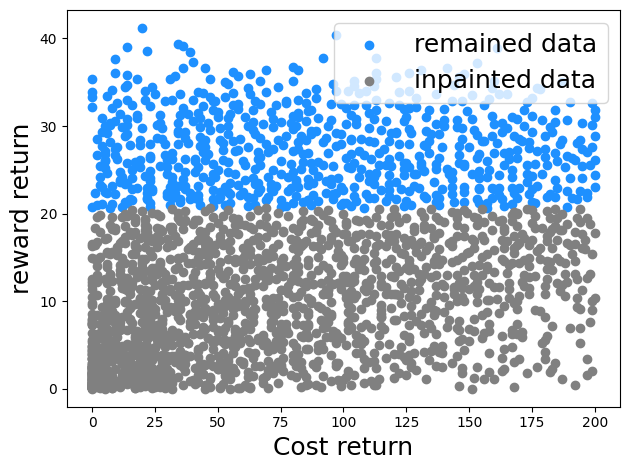

In [11]:
env, obs_dim, act_dim = get_env(task)
main_data = get_dataset_in_d4rl_format(env, trajectory_cfg, task, 1000)

In [12]:
neg_data, union_data = get_neg_and_union_data_2(main_data, trajectory_cfg)
del main_data

Number of negative trajectory dataset: 50
Avg negative trajectory cost/reward: 167.320/27.133
Number of union trajectory dataset: 625
Avg union trajectory cost/reward: 85.154/27.463


In [13]:
neg_z = jnp.array(joblib.load(neg_z_path)['target_neg_z'])

embedding_model = load_embedding_model(
    obs_dim=obs_dim,
    act_dim=act_dim,
    horizon=horizon,
    embd_dim=embd_dim,
    num_attentions=num_attentions,
    path=embedding_path,
)

cost_model = load_cost_model(
    obs_dim=obs_dim,
    act_dim=act_dim,
    hidden_size=hidden_size,
    path=cost_path,
)

In [39]:
def embedding_labels_cost(union_data, embedding_model, neg_z, is_norm, num=10):
    l_pred_embs, l_pred_labels, l_pred_costs, l_true_cost = [], [], [], []
    start, end_len = 0, len(union_data['observations'])
    
    while start < end_len:
        end = start + num
        
        observations, actions, costs = get_data(union_data, start, end)
        embeddings = get_embedding(embedding_model, observations, actions, is_norm)
        pred_labels = predict_trajectory_label(embeddings, neg_z)
        pred_costs = get_pred_cost(cost_model, observations, actions, is_norm)
        true_costs = get_true_cost(costs)

        l_pred_embs.append(embeddings)
        l_pred_labels.append(pred_labels)
        l_pred_costs.append(pred_costs)
        l_true_cost.append(true_costs)
        
        start = end
    
    return (jnp.concat(l_pred_embs, axis=0), jnp.concat(l_pred_labels),
            jnp.concat(l_pred_costs), jnp.concat(l_true_cost))

In [45]:
embeddings, pred_labels, pred_costs, true_costs = embedding_labels_cost(
    union_data, embedding_model, neg_z, is_norm, num=50
)

In [46]:
pred_cost_bins = []
true_cost_bins = []
for i in range(5):
    idx = pred_labels == i
    pred_mean, pred_std = pred_costs[idx].mean().item(), pred_costs[idx].std().item()
    pred_cost_bins.append((pred_mean, pred_std))

    true_mean, true_std = true_costs[idx].mean().item(), true_costs[idx].std().item()
    true_cost_bins.append((true_mean, true_std))


In [47]:
for p, t in zip(pred_cost_bins, true_cost_bins):
    print(p, t)

(383.7977294921875, 3.387923240661621) (80.55460357666016, 52.01907730102539)
(nan, nan) (nan, nan)
(386.24884033203125, 0.1568145751953125) (95.5, 40.5)
(418.7725524902344, 14.714122772216797) (157.43243408203125, 35.46489715576172)
(nan, nan) (nan, nan)
